<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/SistemasInteligentes/SistemasInteligentes_ClassificadorCavalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# biblioteca q/ gerência downloads kaggle
import kagglehub
# executa função do dataset e python baixa arquivos e salva cominho da pasta
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
# caminho onde os arquivos foram salvos
print("Pasta que as imagens estão guardadas:", path)

In [ ]:
# qtd de imagens
import os
# copia arquivos do cache oculto para o drive
import shutil
from google.colab import drive

drive.mount('/content/drive')

# define diretorio onde o dataset foi baixado
diretorio_dataset = "/root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27"

# definição pasta drive
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes/datasetCavalos"
os.makedirs(diretorio_destinoDrive, exist_ok=True)

# inicializando contador img
total_imagem = 0;

# percorrer todas as imagens, comando os.walk, percorre todas as pastas e subpastas do caminho
for raiz, pastas, arquivos in os.walk(diretorio_dataset):
  for arquivo in arquivos:
    # verifica se o arquivo é uma img (ve o fim)
    if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
      total_imagem += 1
      # descobre extensão do arquivo
      extensao = os.path.splitext(arquivo)[1]
      # renomeando as copias
      nomeCopias = f"{total_imagem}{extensao}"
      # copia imgs de pastas e subpastas em um unico lugar no drive
      shutil.copy(
          os.path.join(raiz, arquivo),
          os.path.join(diretorio_destinoDrive, nomeCopias)
      )
print(f"Total de imagens: {total_imagem}")
print(f"Salvas em: {diretorio_destinoDrive}")

In [ ]:
# Apenas inicialização e conexão drive - Inicio daqui apos salvar dados no drive
import os
from google.colab import drive
from google.colab.patches import cv2_imshow
# Monta o drive para acessar os arquivos salvos ontem
drive.mount('/content/drive')

# Definição do caminho da pasta onde as imagens já estão salvas
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes/datasetCavalos"

Mounted at /content/drive


# Pré-processamento
Necessário para usar algoritmos como o k-NN, por não conseguirem interpretar fotos brutas e precisarem que as imagens sejam tranformadas em matrizes numéricas padronizadas e iguais para dai sim, conseguir calcular a distância geométrica entre elas (sua vizinhança).

- **1** Converter para tons de cinza.
- **2** Redimensionar a Imagem  - Resize
- **3** Imagem Achatada
- **4** Ajuste tipos de dados.
    

FLUXO DE EXECUÇÃO: RAIO-X DO PRÉ-PROCESSAMENTO
-------------------------------------------------------
A) IMAGEM SELECIONADA PARA ANÁLISE:


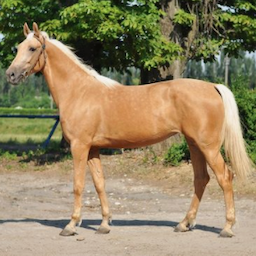

-------------------------------------------------------
MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA
Formato original da imagem (Estrutura física): (256, 256, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
MÉTRICAS DO RESUMO FINAL DO DATASET
Formato final pronto para o k-NN: (670, 4096)
Tipo do dado final na memória: float32
B) IMAGEM APÓS CONVERSÃO DE TONS E REDIMENSIONAMENTO:


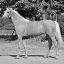

-------------------------------------------------------
C) VETOR DE CARACTERISTICAS CRIADO APÓS ACHATAR IMAGEM E TROCA DE TIPO:
Visualização dos 10 primeiros pixels no vetor:
 [119. 142. 134. 148. 107.  77.  32.  45.  36.  55.]
-------------------------------------------------------


In [ ]:
import numpy as np
import cv2 as cv
import os

# Listar arquivos que estão dentro da pasta do Drive
arquivos = os.listdir(diretorio_destinoDrive)
# Listas para armazenar os resultados
resultadoVetores = []

for nome_arquivo in arquivos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive, nome_arquivo)
    # Carrega a imagem atual
    img_original = cv.imread(caminhoCompleto)
    # converter imgs para tons de cinza
    imgCinza = cv.cvtColor(img_original, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada = cv.resize(imgCinza, tamanhoPadrao)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada = imgRedimensionada.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada.astype(np.float32)

    resultadoVetores.append(vetorCaracteristicas)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_np = np.array(resultadoVetores)

print("FLUXO DE EXECUÇÃO: RAIO-X DO PRÉ-PROCESSAMENTO")
print("-" * 55)
print("A) IMAGEM SELECIONADA PARA ANÁLISE:")
cv2_imshow(img_original)
print("-" * 55)

print("MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA")
print("Formato original da imagem (Estrutura física):", img_original.shape)
print("Tipo de dado original da imagem na memória:", img_original.dtype)
print("-" * 55)

print("MÉTRICAS DO RESUMO FINAL DO DATASET")
print("Formato final pronto para o k-NN:", resultadoVetores_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_np.dtype)
print("B) IMAGEM APÓS CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada)
print("-" * 55)

print("C) VETOR DE CARACTERISTICAS CRIADO APÓS ACHATAR IMAGEM E TROCA DE TIPO:")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

###Extração de Características:
# 1) Bordas e Gradientes

Nesta célula, inicio a extração de características aplicando filtros matemáticos independentes sobre a matriz de $64 \times 64$ em tons de cinza. A partir de uma única imagem de entrada, gero **3 matrizes de características totalmente distintas** para entregar ao k-NN:

1. **Sobel X:** Destaca as **bordas verticais** (caminha no eixo X e captura linhas em pé, como as pernas do animal).
2. **Sobel Y:** Destaca as **bordas horizontais** (caminha no eixo Y e captura linhas deitadas, como o dorso).
3. **Laplaciano:** Mapeia o **relevo geral**, capturando todas as direções de contorno de uma só vez.

**Nota Matemática de Implementação:** As transições de cor geram valores positivos e negativos na memória. Por isso, utilizo obrigatoriamente a profundidade `cv.CV_64F` para preservar os gradientes negativos, aplico o valor absoluto com `np.absolute()` e garanto o tipo final em `float32` exigido pelo cálculo de distância do k-NN.

* **Hiperparâmetros configuráveis de teste:** Tamanho do Kernel (`ksize`), Direção da Derivada (`xorder`/`yorder`) e a variação estável do Filtro de Scharr.

Visualização - Característica 1: Sobel X (Bordas Verticais)


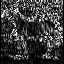

-------------------------------------------------------
Visualização - Característica 2: Sobel Y (Bordas Horizontais)


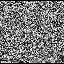

-------------------------------------------------------
Visualização - Característica 3: Laplacian X (Todas as bordas)


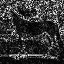

-------------------------------------------------------


In [ ]:
# Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
sobel_x_float = cv.Sobel(imgRedimensionada, cv.CV_64F, 1, 0, ksize=3)
# tranforma negativos em positivos
sobel_x_absoluto = np.absolute(sobel_x_float)
# tipo para o uso do knn
caracteristica_1 = sobel_x_absoluto.astype(np.float32)

# Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
sobel_y_float = cv.Sobel(imgRedimensionada, cv.CV_64F, 0, 1, ksize=5)
sobel_y_absoluto = np.absolute(sobel_y_float)
caracteristica_2 = sobel_y_absoluto.astype(np.float32)

# Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
laplacian_float = cv.Laplacian(imgRedimensionada, cv.CV_64F)
# tranforma negativos em positivos
laplacian_absoluto = np.absolute(laplacian_float)
# tipo para o uso do knn
caracteristica_3 = laplacian_absoluto.astype(np.float32)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x = np.uint8(sobel_x_absoluto)
imagem_visual_y = np.uint8(sobel_y_absoluto)
imagem_visual_lap = np.uint8(laplacian_absoluto)

print("Visualização - Característica 1: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x)
print("-" * 55)
print("Visualização - Característica 2: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y)
print("-" * 55)
print("Visualização - Característica 3: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap)
print("-" * 55)

# Filtros de Textura e Frequência (Suavização e Nitidez)
# Operações Morfológicas (Formas Estruturais)

In [ ]:
# Organização - agrupa os vetores de todas as imgs em uma matriz Numpy

In [ ]:
# Treino (KNN/SVM) - alimenta o cv.ml.KNearest_creat() com a matriz e as etiquetas

In [ ]:
# Salvar modelo - salvar aprendizado em arquivo xml